# Notebook 4 — Does the population encode the block?

**Summer course: data-analysis pitfalls**

In this task a hidden binary **block** variable stays constant for a run of
trials, then flips: `-1, -1, ..., +1, +1, ..., -1, ...` (each block is 30-70
trials long). You have the trial-by-trial activity of 100 simultaneously
recorded neurons across one session, and you want to know whether the population
encodes the block. A colleague trained a linear decoder (LDA) with standard
cross-validation:

> ### The claim
> *"The population robustly encodes the block variable: a linear decoder reads
> it out at ~95% accuracy (cross-validated), far above the 50% chance level."*

Run it and you'll get ~95%.

**The claim is not supported by this analysis.** Work out *why*. A hint to sit
with: the block variable changes slowly (it is constant for tens of trials in a
row). What does ordinary k-fold cross-validation do with a *slow* variable?
`hints.md` has more; `notebook4_solution.ipynb` has the answer.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold, cross_val_predict

plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

def make_blocks(rng, n_trials=None, n_blocks=10, lo=30, hi=70, fixed=None):
    """Alternating +/-1 blocks, uniform-random lengths (lo..hi), random start
    sign. Pass n_trials to fill/truncate to exactly that many trials (handy for
    making pseudosessions); otherwise returns n_blocks blocks and their ids."""
    sign = rng.choice([-1, 1]); values, ids, i = [], [], 0
    if n_trials is None:
        lengths = [fixed]*n_blocks if fixed else rng.integers(lo, hi+1, size=n_blocks)
        for i, L in enumerate(lengths):
            values += [sign*(-1)**i]*int(L); ids += [i]*int(L)
        return np.array(values), np.array(ids)
    while len(values) < n_trials:
        L = fixed if fixed else rng.integers(lo, hi+1)
        values += [sign*(-1)**i]*int(L); i += 1
    return np.array(values[:n_trials]), None

def trialwise_cv(X, y, folds=10, seed=0):
    """Ordinary k-fold CV over trials (trials are shuffled into folds)."""
    kf = KFold(folds, shuffle=True, random_state=seed)
    return np.mean([LinearDiscriminantAnalysis().fit(X[tr], y[tr]).score(X[te], y[te])
                    for tr, te in kf.split(X)])

def blockout_cv(X, y, block_ids):
    """Leave-one-block-out CV: hold out each whole block in turn."""
    return np.array([LinearDiscriminantAnalysis().fit(X[block_ids != b], y[block_ids != b])
                     .score(X[block_ids == b], y[block_ids == b])
                     for b in np.unique(block_ids)])

def pseudo_null(X, n_trials, rng, n=150, fixed=None, folds=5):
    """Trial-wise decoding accuracy for many surrogate ('pseudo') block
    sequences with the same statistics but independent of the neural data."""
    return np.array([trialwise_cv(X, make_blocks(rng, n_trials=n_trials, fixed=fixed)[0],
                                  folds=folds, seed=1) for _ in range(n)])


In [2]:
d = np.load('data/dataset_1.npz')
activity = d['activity']              # (neurons, trials)
block_values = d['block_values']     # +/-1 per trial (the thing we decode)
block_ids = d['block_ids']           # which block each trial belongs to
X = activity.T                       # sklearn wants (samples, features) = (trials, neurons)
y = block_values
n_neurons, n_trials = activity.shape
print(f'{n_neurons} neurons x {n_trials} trials')


100 neurons x 516 trials


## The data


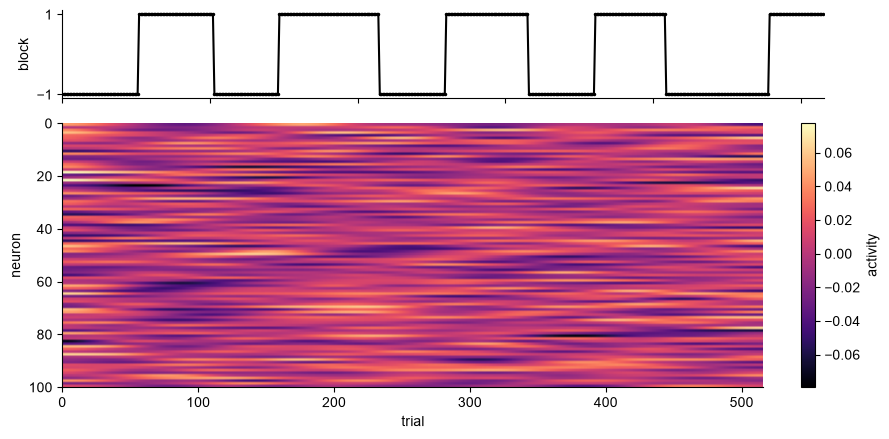

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True,
                         gridspec_kw={'height_ratios': [1, 3]})
axes[0].plot(block_values, '.-', ms=3, color='k')
axes[0].set_ylabel('block'); axes[0].set_yticks([-1, 1])
im = axes[1].imshow(activity, aspect='auto', cmap='magma',
                    extent=[0, n_trials, n_neurons, 0])
axes[1].set_xlabel('trial'); axes[1].set_ylabel('neuron')
plt.colorbar(im, ax=axes[1], label='activity', orientation='vertical', fraction=0.03)
plt.tight_layout()
plt.show()


## How the block sequence was generated

Blocks alternate `+1 / -1`; each block's length is drawn uniformly from 30-70
trials; the first block's sign is random. In code:


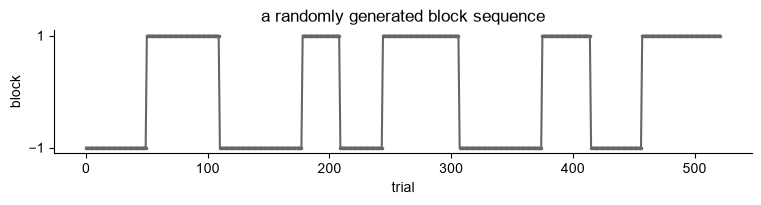

In [4]:
# Example of the generative process (also handy later): draw a block sequence.
example_blocks, _ = make_blocks(np.random.default_rng(1))
plt.figure(figsize=(9, 1.6))
plt.plot(example_blocks, '.-', ms=3, color='0.4')
plt.xlabel('trial'); plt.ylabel('block'); plt.yticks([-1, 1])
plt.title('a randomly generated block sequence'); plt.show()


## Decode the block with cross-validation


In [5]:
acc = trialwise_cv(X, y)      # standard k-fold CV over trials
print(f'Trial-wise cross-validated decoding accuracy: {acc*100:.1f}%  (chance = 50%)')


Trial-wise cross-validated decoding accuracy: 97.7%  (chance = 50%)


~95%, far above chance. Case closed -- the population encodes the block. ...or
does it?
